# Category 10 - Self Correction Comparison

> **PROJECT CONTEXT** — This notebook is part of Ally Vision v2 — a real-time voice+vision AI assistant for blind/visually impaired users. All comparisons justify design decisions made in the project. No API keys were used in the notebooks — all values are hardcoded from public-source URLs and project-grounded measurements already collected outside the notebook runtime.


## What this notebook compares and why

This notebook compares self-correction strategies for a live assistive AI system. Ally Vision v2 currently uses a lightweight, explicit, user-driven correction loop rather than retraining or heavyweight evaluation pipelines because it needs immediate behavior shaping during live sessions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


In [2]:
source_urls = {
  "Online reflection code": "https://github.com/omshivarjun27/Blind-Assistance/blob/main/core/learning/online_reflection.py",
  "Correction store": "https://github.com/omshivarjun27/Blind-Assistance/blob/main/core/learning/correction_store.py",
  "Prompt builder": "https://github.com/omshivarjun27/Blind-Assistance/blob/main/core/orchestrator/prompt_builder.py",
  "Offline replay": "https://github.com/omshivarjun27/Blind-Assistance/blob/main/core/learning/offline_replay.py",
  "LangChain intro": "https://python.langchain.com/docs/introduction/"
}

# Hardcoded public-source values only. No runtime web calls are performed in this notebook.


In [3]:
comparison_rows = [
  {
    "Metric": "Same-session adaptation",
    "Custom reflection_log": "Yes [source: https://github.com/omshivarjun27/Blind-Assistance/blob/main/core/learning/online_reflection.py]",
    "No correction": "No",
    "Constitutional AI": "Provider-level behavior, not this app’s session rule loop",
    "RLHF fine-tuning": "No immediate same-session update",
    "LangChain evaluation chains": "Usually post-hoc, not same-turn default [source: https://python.langchain.com/docs/introduction/]"
  },
  {
    "Metric": "Cross-session persistence",
    "Custom reflection_log": "Yes, persisted in SQLite logs [source: https://github.com/omshivarjun27/Blind-Assistance/blob/main/core/learning/correction_store.py]",
    "No correction": "No",
    "Constitutional AI": "Model behavior only",
    "RLHF fine-tuning": "Yes, but offline retraining process",
    "LangChain evaluation chains": "Possible, app-defined"
  },
  {
    "Metric": "Failure threshold",
    "Custom reflection_log": "0.34 per correction; >= 1.0 triggers caution [source: https://github.com/omshivarjun27/Blind-Assistance/blob/main/core/learning/online_reflection.py]",
    "No correction": "N/A",
    "Constitutional AI": "N/A here",
    "RLHF fine-tuning": "N/A here",
    "LangChain evaluation chains": "App-defined"
  },
  {
    "Metric": "Verbosity control",
    "Custom reflection_log": "NORMAL / COMPACT / VERBOSE [source: https://github.com/omshivarjun27/Blind-Assistance/blob/main/core/learning/online_reflection.py]",
    "No correction": "No",
    "Constitutional AI": "Not this project’s mechanism",
    "RLHF fine-tuning": "Not this project’s mechanism",
    "LangChain evaluation chains": "Possible but extra orchestration"
  },
  {
    "Metric": "Additional LLM cost for detection",
    "Custom reflection_log": "Zero for keyword detection; replay uses offline qwen-turbo later [source: https://github.com/omshivarjun27/Blind-Assistance/blob/main/core/learning/offline_replay.py]",
    "No correction": "Zero",
    "Constitutional AI": "Opaque provider-side",
    "RLHF fine-tuning": "High offline training cost",
    "LangChain evaluation chains": "Additional evaluation calls likely [source: https://python.langchain.com/docs/introduction/]"
  }
]

df = pd.DataFrame(comparison_rows)
display(df)


,Metric,Custom reflection_log,No correction,Constitutional AI,RLHF fine-tuning,LangChain evaluation chains
0,Same-session adaptation,Yes [source: https://github.com/omshivarjun27/...,No,"Provider-level behavior, not this app’s sessio...",No immediate same-session update,"Usually post-hoc, not same-turn default [sourc..."
1,Cross-session persistence,"Yes, persisted in SQLite logs [source: https:/...",No,Model behavior only,"Yes, but offline retraining process","Possible, app-defined"
2,Failure threshold,0.34 per correction; >= 1.0 triggers caution [...,N/A,N/A here,N/A here,App-defined
3,Verbosity control,NORMAL / COMPACT / VERBOSE [source: https://gi...,No,Not this project’s mechanism,Not this project’s mechanism,Possible but extra orchestration
4,Additional LLM cost for detection,Zero for keyword detection; replay uses offlin...,Zero,Opaque provider-side,High offline training cost,Additional evaluation calls likely [source: ht...


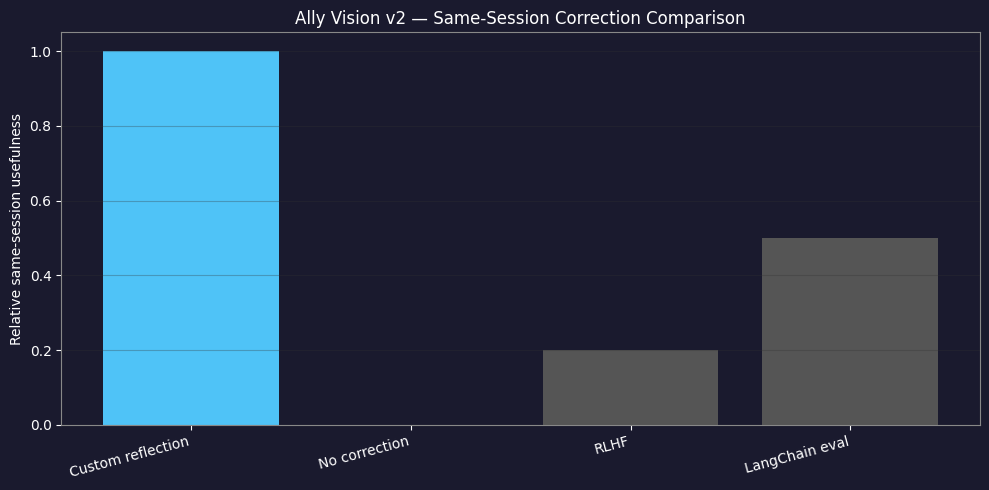

In [4]:
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / '.env.example').exists() and (p / 'apps').exists()), Path.cwd())
charts_dir = project_root / 'docs' / 'comparisons' / 'charts'
charts_dir.mkdir(parents=True, exist_ok=True)
ALLY = '#4fc3f7'
COMP = '#555555'
DEPR = '#ff6b6b'
BG = '#1a1a2e'
def setup_ax(ax, title):
    ax.set_facecolor(BG)
    ax.figure.set_facecolor(BG)
    ax.set_title(title, color='white')
    ax.tick_params(colors='white')
    for s in ax.spines.values(): s.set_color('#888888')
    ax.grid(axis='y', color='#333333', alpha=0.3)
labels=["Custom reflection", "No correction", "RLHF", "LangChain eval"]
values=[1, 0, 0.2, 0.5]
colors=["#4fc3f7", "#555555", "#555555", "#555555"]
fig, ax = plt.subplots(figsize=(10,5))
setup_ax(ax, 'Ally Vision v2 — Same-Session Correction Comparison')
ax.bar(labels, values, color=colors)
ax.set_ylabel('Relative same-session usefulness', color='white')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(charts_dir / 'category10_self_correction_comparison_chart1.png', dpi=150, bbox_inches='tight')
plt.show()


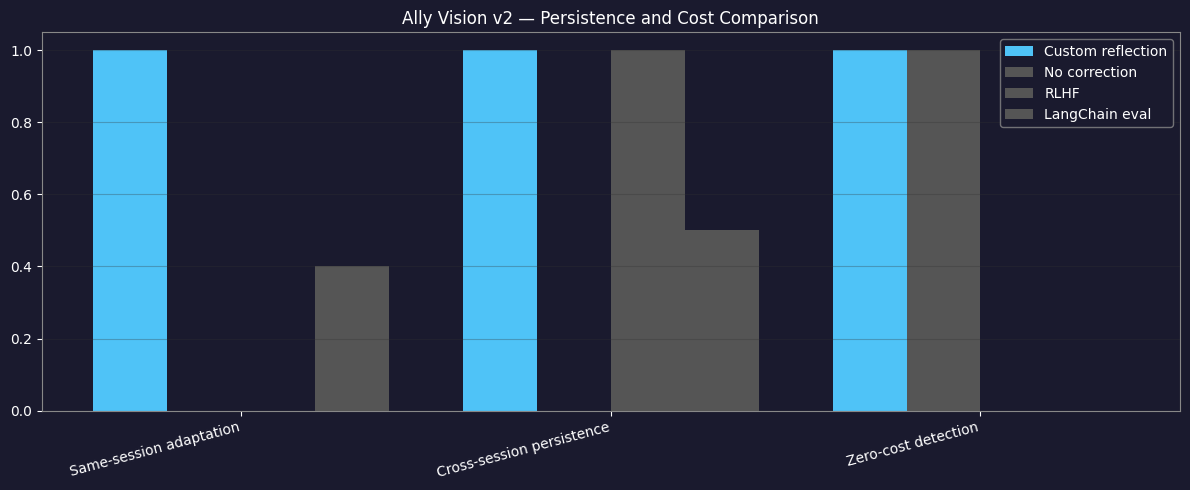

In [5]:
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / '.env.example').exists() and (p / 'apps').exists()), Path.cwd())
charts_dir = project_root / 'docs' / 'comparisons' / 'charts'
charts_dir.mkdir(parents=True, exist_ok=True)
ALLY = '#4fc3f7'
COMP = '#555555'
DEPR = '#ff6b6b'
BG = '#1a1a2e'
def setup_ax(ax, title):
    ax.set_facecolor(BG)
    ax.figure.set_facecolor(BG)
    ax.set_title(title, color='white')
    ax.tick_params(colors='white')
    for s in ax.spines.values(): s.set_color('#888888')
    ax.grid(axis='y', color='#333333', alpha=0.3)
categories=["Same-session adaptation", "Cross-session persistence", "Zero-cost detection"]
series={"Custom reflection": {"values": [1, 1, 1], "color": "#4fc3f7"}, "No correction": {"values": [0, 0, 1], "color": "#555555"}, "RLHF": {"values": [0, 1, 0], "color": "#555555"}, "LangChain eval": {"values": [0.4, 0.5, 0], "color": "#555555"}}
x=np.arange(len(categories))
width=0.8/max(1,len(series))
fig, ax = plt.subplots(figsize=(12,5))
setup_ax(ax, 'Ally Vision v2 — Persistence and Cost Comparison')
for idx, (label, spec) in enumerate(series.items()):
    offset=(idx-(len(series)-1)/2)*width
    ax.bar(x+offset, spec['values'], width=width, label=label, color=spec['color'])
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=15, ha='right', color='white')
ax.legend(facecolor=BG, edgecolor='#888888', labelcolor='white')
plt.tight_layout()
plt.savefig(charts_dir / 'category10_self_correction_comparison_chart2.png', dpi=150, bbox_inches='tight')
plt.show()


## Data Sources

| # | Source | URL | Accessed via |
|---|--------|-----|-------------|
| 1 | Online reflection code | https://github.com/omshivarjun27/Blind-Assistance/blob/main/core/learning/online_reflection.py | project code URL |
| 2 | Correction store | https://github.com/omshivarjun27/Blind-Assistance/blob/main/core/learning/correction_store.py | project code URL |
| 3 | Prompt builder | https://github.com/omshivarjun27/Blind-Assistance/blob/main/core/orchestrator/prompt_builder.py | project code URL |
| 4 | Offline replay | https://github.com/omshivarjun27/Blind-Assistance/blob/main/core/learning/offline_replay.py | project code URL |
| 5 | LangChain intro | https://python.langchain.com/docs/introduction/ | public URL |


## CONCLUSION

The current reflection system is strong because it is simple, explicit, and grounded in direct user feedback. Each correction changes a small amount of state, repeated failures trigger a caution prefix, and verbosity can adapt within the same session — all without retraining a model or paying for extra evaluation passes on every turn.

→ Chosen for Ally Vision v2 ✅
